In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import numpy as np
from scipy.special import assoc_laguerre
from scipy.special import factorial, sph_harm_y # (l, m, θ, ϕ)

In [2]:
def R_nl(n: int, l:int, a0: float, r:float) -> float:
    ρ: float = 2*r / (n*a0)
    norm: float = np.sqrt( np.power(2/(n*a0), 3) * factorial(n-l-1)/(2*n*factorial(n+l)) )
    laguerre: float = assoc_laguerre(ρ, n-l-1, 2*l+1)
    return norm * np.exp(-ρ/2) * np.power(ρ, l) * laguerre

In [3]:
def ϕ_nlm(n:int, l:int, m:int, a0:float, r:float, θ: float, φ: float) -> float:
    R = R_nl(n, l, a0, r)
    Y = sph_harm_y(l, m, θ, φ)
    return R * Y

**Recordatorio.**

La función de onda tiene unidades de

$$ [\Psi] = \text{distancia}^{-3/2} \,.$$

La probabilidad es adimensional. Por lo que, la *densidad de probabilidad* debe de tener unidades de

$$ [\rho] = [\,|\Psi|^2\,] = \text{distancia}^{-3} = \frac{1}{\text{volumen}} \,.$$

## Densidad de probabilidad

La densidad de probabilidad es

$$ \rho(\mathbf{r}) = |\psi(\mathbf{r})|^2 = |\psi(r, \theta, \varphi)|^2 $$

In [4]:
def ρ_nlm(n:int, l:int, m:int, a0:float, r:float, θ: float, φ: float) -> float:
    """ Densidad de probabilidad
    (n,l,m) : número cuántico (principal, azimutal, magnético)
    a0 : radio de Bohr
    r : distancia radial
    θ : ángulo azimutal
    φ : ángulo polar
    """
    return np.abs(ϕ_nlm(n, l, m, a0, r, θ, φ))**2

In [5]:
def ρ_mallado(n: int, l: int, m: int, a0: float = 1.0,
              R_data: list = [0, 2, 3],
              θ_data: list = [0, np.pi, 10],
              φ_data: list = [0, 2*np.pi, 10]):
    """ Mallado de densidad de probabilidad
    """
    rmin, rmax, numR = R_data
    θmin, θmax, numθ = θ_data
    φmin, φmax, numφ = φ_data
    
    r = np.linspace(rmin, rmax, numR)
    θ = np.linspace(θmin, θmax, numθ)
    φ = np.linspace(φmin, φmax, numφ)
    R, Theta, Phi = np.meshgrid(r, θ, φ)

    # Calculate density
    densidad = ρ_nlm(n, l, m, a0, R, Theta, Phi)

    # Convert to Cartesian coordinates
    X = R * np.sin(Theta) * np.cos(Phi)
    Y = R * np.sin(Theta) * np.sin(Phi)
    Z = R * np.cos(Theta)
    
    return X, Y, Z, densidad

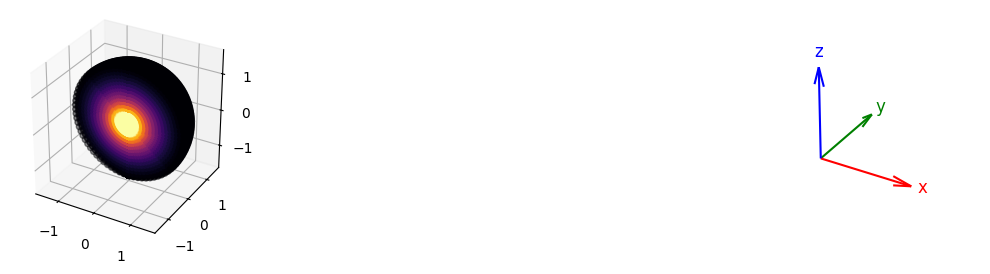

In [6]:
# Plot
fig = plt.figure(figsize=(10, 8))

##################################
n: int = 1
l: int = 0
m: int = 0

a0: float = 1.0
Rmax = 1.5
R_data = [0.3, Rmax, 15]
θ_data = [0, np.pi-0.01, 40]
φ_data = [0, np.pi, 40]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)
ax1 = fig.add_subplot(1,4,1, projection='3d')
# ax.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
#                 rstride=1, cstride=1, antialiased=False, shade=True)
ax1.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax1.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_box_aspect([1, 1, 1])

##################################
ax2 = fig.add_subplot(1,4,4, projection='3d')
ax2.set_xlim(-1, 1)
ax2.set_ylim(-1, 1)
ax2.set_zlim(-1, 1)
ax2.set_box_aspect([1, 1, 1])

# Origin point
x0, y0, z0 = -0.5, -0.5, -0.5
L = 1.5

ax2.quiver(x0, y0, z0, L, 0, 0, color='red',   arrow_length_ratio=0.2, linewidth=1.5)
ax2.quiver(x0, y0, z0, 0, L, 0, color='green', arrow_length_ratio=0.2, linewidth=1.5)
ax2.quiver(x0, y0, z0, 0, 0, L, color='blue',  arrow_length_ratio=0.2, linewidth=1.5)

# Texto de flechas
ax2.text(x0 + L + 0.1, y0, z0 - 0.08, 'x', color='red', fontsize=12)
ax2.text(x0, y0 + L + 0.1, z0, 'y', color='green', fontsize=12)
ax2.text(x0, y0 -0.1, z0 + L + 0.2, 'z', color='blue', fontsize=12)

# Remover texto de los ejes, etiquetas y fondo
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_zticks([])

ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_zlabel('')

ax2.xaxis.pane.set_visible(False)
ax2.yaxis.pane.set_visible(False)
ax2.zaxis.pane.set_visible(False)

# Esto evita que se dibujen los ejes negros
ax2.xaxis.line.set_linewidth(0)
ax2.yaxis.line.set_linewidth(0)
ax2.zaxis.line.set_linewidth(0)


plt.tight_layout()
plt.show()

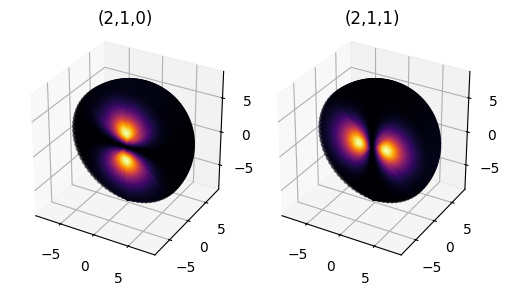

In [7]:
a0: float = 1.0

# Plot
fig = plt.figure(figsize=(10, 8))

##################################
n: int = 2
l: int = 1
m: int = 0

Rmax = 8
R_data = [0.1, Rmax, 40]
θ_data = [0, np.pi-0.01, 40]
φ_data = [0, np.pi, 40]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax1 = fig.add_subplot(1, 4, 1, projection='3d')
# ax2.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
#                 rstride=1, cstride=1, antialiased=False, shade=True)
ax1.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax1.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_title(f"({n},{l},{m})")
ax1.set_box_aspect([1, 1, 1])

##################################
n: int = 2
l: int = 1
m: int = 1

Rmax = 8
R_data = [0.1, Rmax, 40]
θ_data = [0, np.pi, 40]
φ_data = [0, np.pi, 40]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax2 = fig.add_subplot(1, 4, 2, projection='3d')
# ax3.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
#                 rstride=1, cstride=1, antialiased=False, shade=True)
ax2.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax2.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_title(f"({n},{l},{m})")
ax2.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

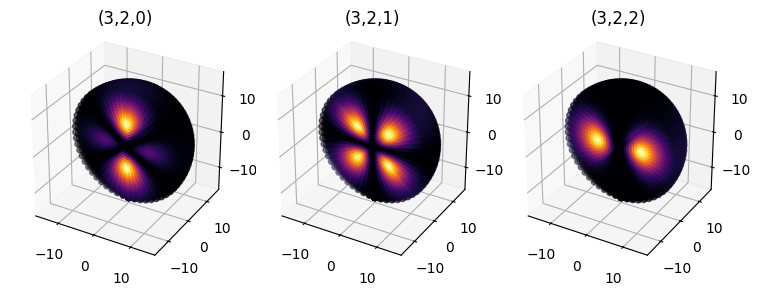

In [8]:
# Plot
fig = plt.figure(figsize=(10, 8))
a0: float = 1.0
##################################
n: int = 3
l: int = 2
m: int = 0

Rmax = 15
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 30]
φ_data = [0, np.pi, 30]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax1 = fig.add_subplot(1, 4, 1, projection='3d')
# ax1.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
#                 rstride=1, cstride=1, antialiased=False, shade=True)
ax1.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax1.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_title(f"({n},{l},{m})")
ax1.set_box_aspect([1, 1, 1])

##################################
n: int = 3
l: int = 2
m: int = 1

Rmax = 15
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 30]
φ_data = [0, np.pi, 30]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax2 = fig.add_subplot(1, 4, 2, projection='3d')
# ax2.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
                # rstride=1, cstride=1, antialiased=False, shade=True)
ax2.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax2.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_title(f"({n},{l},{m})")
ax2.set_box_aspect([1, 1, 1])

##################################
n: int = 3
l: int = 2
m: int = 2

Rmax = 15
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 30]
φ_data = [0, np.pi, 30]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax3 = fig.add_subplot(1, 4, 3, projection='3d')
# ax3.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
                # rstride=1, cstride=1, antialiased=False, shade=True)
ax3.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax3.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax3.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax3.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax3.set_title(f"({n},{l},{m})")
ax3.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

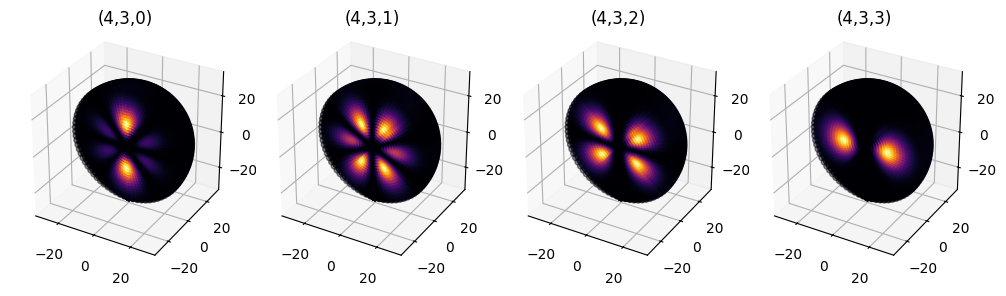

In [9]:
# Plot
fig = plt.figure(figsize=(10, 8))
a0: float = 1.0
##################################
n: int = 4
l: int = 3
m: int = 0

Rmax = 30
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 40]
φ_data = [0, np.pi, 40]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax1 = fig.add_subplot(1, n, n-l, projection='3d')
# ax1.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
#                 rstride=1, cstride=1, antialiased=False, shade=True)
ax1.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax1.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_title(f"({n},{l},{m})")
ax1.set_box_aspect([1, 1, 1])

##################################
n: int = 4
l: int = 3
m: int = 1

Rmax = 30
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 40]
φ_data = [0, np.pi, 40]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax2 = fig.add_subplot(1, n, n-l+m, projection='3d')
# ax2.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
#                 rstride=1, cstride=1, antialiased=False, shade=True)
ax2.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax2.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_title(f"({n},{l},{m})")
ax2.set_box_aspect([1, 1, 1])

##################################
n: int = 4
l: int = 3
m: int = 2

Rmax = 30
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 40]
φ_data = [0, np.pi, 40]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax3 = fig.add_subplot(1, n, n-l+m, projection='3d')
# ax3.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
#                 rstride=1, cstride=1, antialiased=False, shade=True)
ax3.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax3.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax3.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax3.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax3.set_title(f"({n},{l},{m})")
ax3.set_box_aspect([1, 1, 1])

##################################
n: int = 4
l: int = 3
m: int = 3

Rmax = 30
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 40]
φ_data = [0, np.pi, 40]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax4 = fig.add_subplot(1, n, n-l+m, projection='3d')
# ax4.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
#                 rstride=1, cstride=1, antialiased=False, shade=True)
ax4.scatter(X, Y, Z, c=density, cmap='inferno')
# Aesthetics
Rpadd = Rmax*0.1
ax4.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax4.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax4.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax4.set_title(f"({n},{l},{m})")
ax4.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

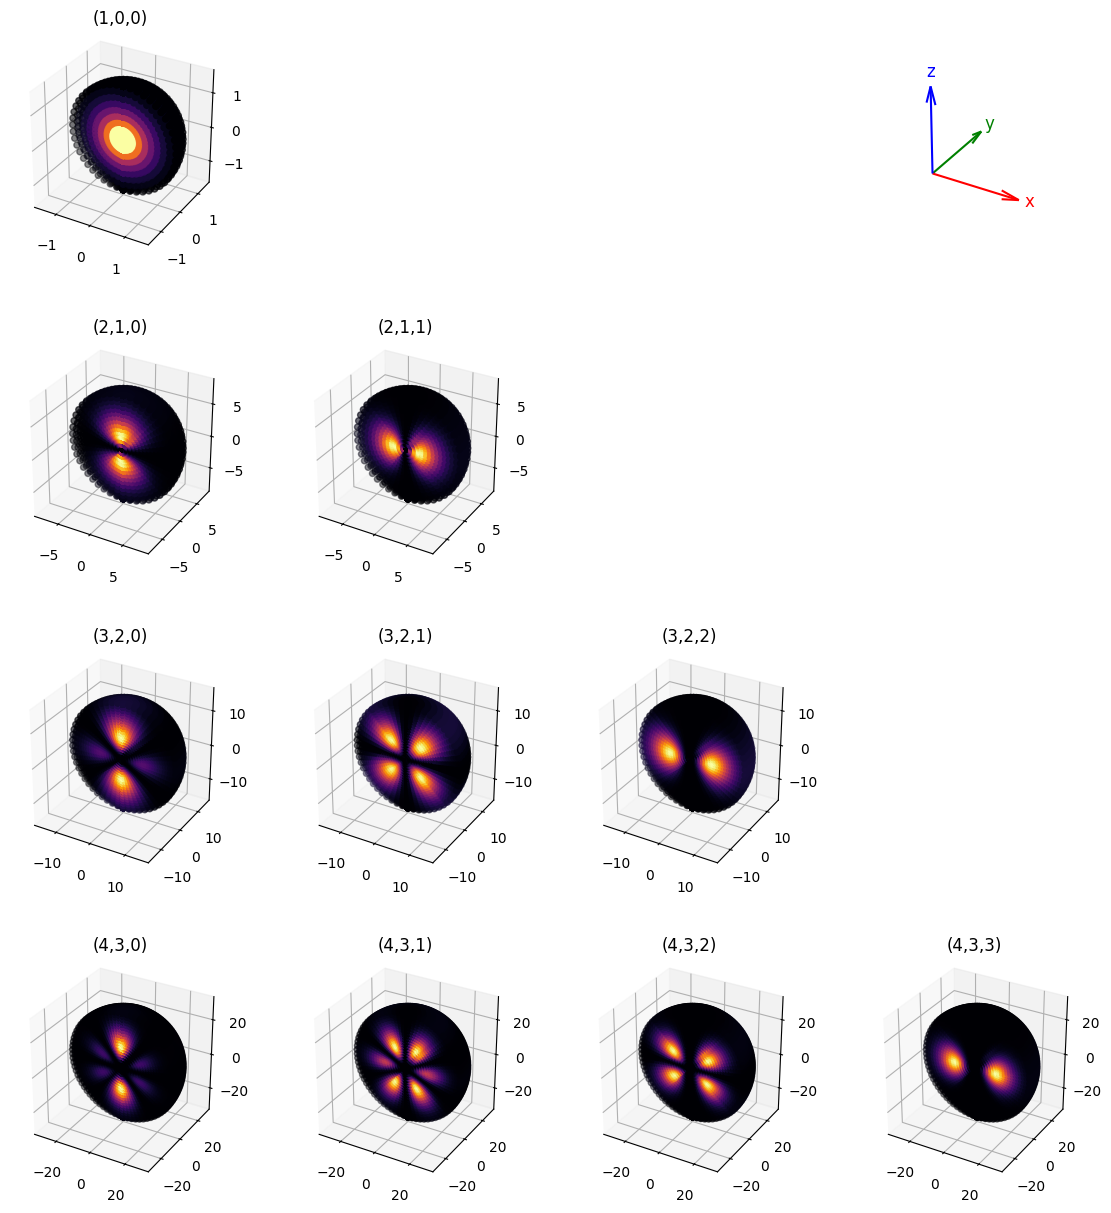

In [10]:
# Plot
fig = plt.figure(figsize=(12, 12))

##################################
###### Primer renglón ############
##################################
n: int = 1
l: int = 0
m: int = 0

a0: float = 1.0
Rmax = 1.5
R_data = [0.3, Rmax, 8]
θ_data = [0, np.pi, 25]
φ_data = [0, np.pi, 25]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax00 = fig.add_subplot(4, 4, 1, projection='3d')
ax00.scatter(X, Y, Z, c=density, cmap='inferno')
Rpadd = Rmax*0.1
ax00.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax00.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax00.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax00.set_title(f"({n},{l},{m})")
ax00.set_box_aspect([1, 1, 1])

##################################
ax03 = fig.add_subplot(4, 4, 4, projection='3d')
ax03.set_xlim(-1, 1)
ax03.set_ylim(-1, 1)
ax03.set_zlim(-1, 1)
ax03.set_box_aspect([1, 1, 1])

# Origin point
x0, y0, z0 = -0.5, -0.5, -0.5
L = 1.5

ax03.quiver(x0, y0, z0, L, 0, 0, color='red',   arrow_length_ratio=0.2, linewidth=1.5)
ax03.quiver(x0, y0, z0, 0, L, 0, color='green', arrow_length_ratio=0.2, linewidth=1.5)
ax03.quiver(x0, y0, z0, 0, 0, L, color='blue',  arrow_length_ratio=0.2, linewidth=1.5)

# Texto de flechas
ax03.text(x0 + L + 0.1, y0, z0 - 0.08, 'x', color='red', fontsize=12)
ax03.text(x0, y0 + L + 0.1, z0, 'y', color='green', fontsize=12)
ax03.text(x0, y0 -0.1, z0 + L + 0.2, 'z', color='blue', fontsize=12)

# Remover texto de los ejes, etiquetas y fondo
ax03.set_xticks([])
ax03.set_yticks([])
ax03.set_zticks([])

ax03.set_xlabel('')
ax03.set_ylabel('')
ax03.set_zlabel('')

ax03.xaxis.pane.set_visible(False)
ax03.yaxis.pane.set_visible(False)
ax03.zaxis.pane.set_visible(False)

# Esto evita que se dibujen los ejes negros
ax03.xaxis.line.set_linewidth(0)
ax03.yaxis.line.set_linewidth(0)
ax03.zaxis.line.set_linewidth(0)

##################################
###### Segundo renglón ###########
##################################
n: int = 2
l: int = 1
m: int = 0

Rmax = 8
R_data = [0.1, Rmax, 15]
θ_data = [0, np.pi, 25]
φ_data = [0, np.pi, 25]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax10 = fig.add_subplot(4, 4, 5, projection='3d')
ax10.scatter(X, Y, Z, c=density, cmap='inferno')
Rpadd = Rmax*0.1
ax10.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax10.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax10.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax10.set_title(f"({n},{l},{m})")
ax10.set_box_aspect([1, 1, 1])

##################################
n: int = 2
l: int = 1
m: int = 1

Rmax = 8
R_data = [0.1, Rmax, 15]
θ_data = [0, np.pi, 25]
φ_data = [0, np.pi, 25]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax21 = fig.add_subplot(4, 4, 6, projection='3d')
ax21.scatter(X, Y, Z, c=density, cmap='inferno')
Rpadd = Rmax*0.1
ax21.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax21.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax21.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax21.set_title(f"({n},{l},{m})")
ax21.set_box_aspect([1, 1, 1])

##################################
####### Tercer renglón ###########
##################################

n: int = 3
l: int = 2
m: int = 0

Rmax = 15
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 30]
φ_data = [0, np.pi, 30]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax20 = fig.add_subplot(4, 4, 9, projection='3d')
ax20.scatter(X, Y, Z, c=density, cmap='inferno')
Rpadd = Rmax*0.1
ax20.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax20.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax20.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax20.set_title(f"({n},{l},{m})")
ax20.set_box_aspect([1, 1, 1])

##################################
n: int = 3
l: int = 2
m: int = 1

Rmax = 15
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 30]
φ_data = [0, np.pi, 30]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax21 = fig.add_subplot(4, 4, 10, projection='3d')
ax21.scatter(X, Y, Z, c=density, cmap='inferno')
Rpadd = Rmax*0.1
ax21.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax21.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax21.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax21.set_title(f"({n},{l},{m})")
ax21.set_box_aspect([1, 1, 1])

##################################
n: int = 3
l: int = 2
m: int = 2

Rmax = 15
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 30]
φ_data = [0, np.pi, 30]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax22 = fig.add_subplot(4, 4, 11, projection='3d')
ax22.scatter(X, Y, Z, c=density, cmap='inferno')
Rpadd = Rmax*0.1
ax22.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax22.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax22.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax22.set_title(f"({n},{l},{m})")
ax22.set_box_aspect([1, 1, 1])

##################################
####### Cuarto renglón ###########
##################################
n: int = 4
l: int = 3
m: int = 0

Rmax = 30
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 40]
φ_data = [0, np.pi, 40]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax30 = fig.add_subplot(4, 4, 13, projection='3d')
ax30.scatter(X, Y, Z, c=density, cmap='inferno')
Rpadd = Rmax*0.1
ax30.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax30.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax30.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax30.set_title(f"({n},{l},{m})")
ax30.set_box_aspect([1, 1, 1])

##################################
n: int = 4
l: int = 3
m: int = 1

Rmax = 30
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 40]
φ_data = [0, np.pi, 40]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax31 = fig.add_subplot(4, 4, 14, projection='3d')
ax31.scatter(X, Y, Z, c=density, cmap='inferno')
Rpadd = Rmax*0.1
ax31.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax31.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax31.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax31.set_title(f"({n},{l},{m})")
ax31.set_box_aspect([1, 1, 1])

##################################
n: int = 4
l: int = 3
m: int = 2

Rmax = 30
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 40]
φ_data = [0, np.pi, 40]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax32 = fig.add_subplot(4, 4, 15, projection='3d')
ax32.scatter(X, Y, Z, c=density, cmap='inferno')
Rpadd = Rmax*0.1
ax32.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax32.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax32.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax32.set_title(f"({n},{l},{m})")
ax32.set_box_aspect([1, 1, 1])

##################################
n: int = 4
l: int = 3
m: int = 3

Rmax = 30
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 40]
φ_data = [0, np.pi, 40]
X, Y, Z, density = ρ_mallado(n, l, m, a0, R_data, θ_data, φ_data)

ax33 = fig.add_subplot(4, 4, 16, projection='3d')
ax33.scatter(X, Y, Z, c=density, cmap='inferno')
Rpadd = Rmax*0.1
ax33.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax33.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax33.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax33.set_title(f"({n},{l},{m})")
ax33.set_box_aspect([1, 1, 1])

########################################
########################################
plt.tight_layout()
plt.subplots_adjust(wspace=-0.1, hspace=0.4)

plt.savefig("H_densidadProb.png", dpi=300, bbox_inches='tight')

plt.show()

## Densidades de prob. que no son densidades

Hay muchas gráficas de estos cortes transversales en internet, sin embargo si uno presta atención a ello lo que están graficando es

$$ r^2 |\psi(\mathbf{r})|^2 = r^2 |\psi(r, \theta, \varphi)|^2 \,.$$

El integrando de la probabilidad sobre todo el espacio, por alguna mística razón que desconozco.

In [11]:
def ρ_nlm_mala(n:int, l:int, m:int, a0:float, r:float, θ: float, φ: float) -> float:
    """ Densidad de probabilidad
    (n,l,m) : número cuántico (principal, azimutal, magnético)
    a0 : radio de Bohr
    r : distancia radial
    θ : ángulo azimutal
    φ : ángulo polar
    """
    return np.square(r) * np.square(np.abs(ϕ_nlm(n, l, m, a0, r, θ, φ)))

In [12]:
def ρ_mallado_malo(n: int, l: int, m: int, a0: float = 1.0,
              R_data: list = [0, 2, 3],
              θ_data: list = [0, np.pi, 10],
              φ_data: list = [0, 2*np.pi, 10]):
    """ Mallado de densidad de probabilidad
    """
    rmin, rmax, numR = R_data
    θmin, θmax, numθ = θ_data
    φmin, φmax, numφ = φ_data
    
    r = np.linspace(rmin, rmax, numR)
    θ = np.linspace(θmin, θmax, numθ)
    φ = np.linspace(φmin, φmax, numφ)
    R, Theta, Phi = np.meshgrid(r, θ, φ)

    # Calculate density
    densidad = ρ_nlm_mala(n, l, m, a0, R, Theta, Phi)

    # Convert to Cartesian coordinates
    X = R * np.sin(Theta) * np.cos(Phi)
    Y = R * np.sin(Theta) * np.sin(Phi)
    Z = R * np.cos(Theta)
    
    return X, Y, Z, densidad

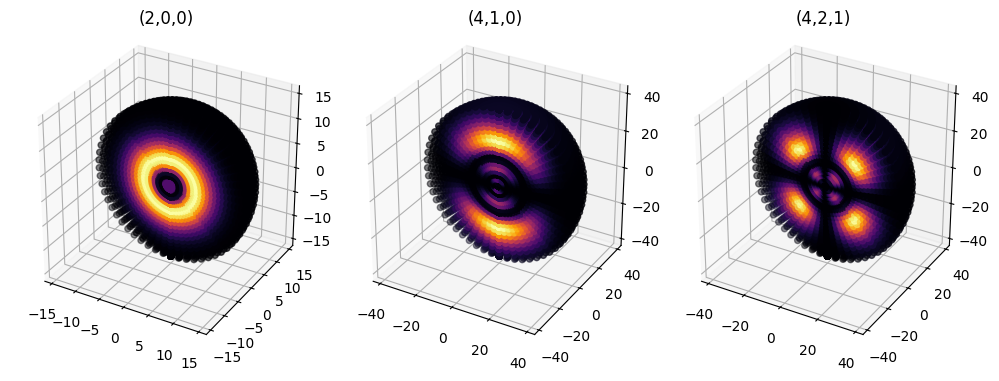

In [13]:
# Plot
fig = plt.figure(figsize=(10, 8))
a0: float = 1.0
##################################
n: int = 2
l: int = 0
m: int = 0

Rmax = 15
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 30]
φ_data = [0, np.pi, 30]
X, Y, Z, density = ρ_mallado_malo(n, l, m, a0, R_data, θ_data, φ_data)

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
# ax1.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
#                 rstride=1, cstride=1, antialiased=False, shade=True)
ax1.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax1.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax1.set_title(f"({n},{l},{m})")
ax1.set_box_aspect([1, 1, 1])

##################################
n: int = 4
l: int = 1
m: int = 0

Rmax = 40
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 30]
φ_data = [0, np.pi, 30]
X, Y, Z, density = ρ_mallado_malo(n, l, m, a0, R_data, θ_data, φ_data)

ax2 = fig.add_subplot(1, 3, 2, projection='3d')
# ax2.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
                # rstride=1, cstride=1, antialiased=False, shade=True)
ax2.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax2.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax2.set_title(f"({n},{l},{m})")
ax2.set_box_aspect([1, 1, 1])

##################################
n: int = 4
l: int = 2
m: int = 1

Rmax = 40
R_data = [1, Rmax, 20]
θ_data = [0, np.pi, 30]
φ_data = [0, np.pi, 30]
X, Y, Z, density = ρ_mallado_malo(n, l, m, a0, R_data, θ_data, φ_data)

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
# ax3.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(density / np.max(density)),
                # rstride=1, cstride=1, antialiased=False, shade=True)
ax3.scatter(X, Y, Z, c=density, cmap='inferno')

# Aesthetics
Rpadd = Rmax*0.1
ax3.set_xlim(-Rmax-Rpadd, Rmax+Rpadd)
ax3.set_ylim(-Rmax-Rpadd, Rmax+Rpadd)
ax3.set_zlim(-Rmax-Rpadd, Rmax+Rpadd)
ax3.set_title(f"({n},{l},{m})")
ax3.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

---

## Densidad radial de probabilidad

$$ \rho_r(r) = r^2|R_{nl}(r)|^2 $$

Observación: Esto no es una densidad de probabilidad en el sentido estricto.

In [14]:
def ρr_nlm(n:int, l:int, m:int, a0:float, r:float) -> float:
    """ 'Densidad' de probabilidad radial
    (n,l,m) : número cuántico (principal, azimutal, magnético)
    a0 : radio de Bohr
    r : distancia radial
    θ : ángulo azimutal
    φ : ángulo polar
    """    
    return np.square(r) * np.square(np.abs(R_nl(n, l, a0, r)))

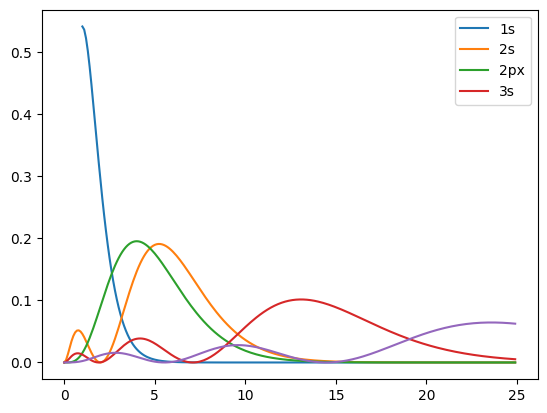

In [15]:
r = np.arange(1, 25, 0.1)
plt.plot(r, ρr_nlm(1,0,0,1,r), label='1s')

r = np.arange(0, 25, 0.1)
plt.plot(r, ρr_nlm(2,0,0,1,r), label='2s')

r = np.arange(0, 25, 0.1)
plt.plot(r, ρr_nlm(2,1,0,1,r), label='2px')

r = np.arange(0, 25, 0.1)
plt.plot(r, ρr_nlm(3,0,0,1,r), label='3s')

r = np.arange(0, 25, 0.1)
plt.plot(r, ρr_nlm(4,1,0,1,r))

plt.legend()
plt.show()